| # | Problem | Objective | Data Mining Technique |
|---|---------|-----------|----------------------|
| 1 | Opioid involvement prediction | Classify deaths as opioid/non-opioid using demographic and substance features | Classification (Random Forest + SVM) |
| 2 | Substance trend forecasting | Predict yearly substance counts using regression models | Prediction (Linear + Polynomial Regression) |
| 3 | Geographic hotspot identification | Discover spatial clusters of overdose deaths | Clustering (K-Means + DBSCAN) |
| 4 | Anomalous case detection | Flag unusual overdose cases that deviate from normal patterns | Anomaly Detection (Isolation Forest + LOF) |


---
## 1.Data Preprocessing

This section documents all preprocessing steps applied to the raw dataset to prepare it for data mining tasks. Each step includes before/after verification to ensure correctness.

**Preprocessing categories applied:**
1. **Data Cleaning** — Fix inconsistencies, standardise values, handle missing data
2. **Data Transformation** — Feature engineering, encoding, scaling
3. **Data Integration** — Extract geographic coordinates from geocoded strings
4. **Data Reduction** — Remove redundant/irrelevant columns


### 1.1 Setup and Load Raw Dataset

In [1]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)

# Step 2: Load the raw dataset
df = pd.read_csv('Accidental_Drug_Related_Deaths.csv')

print("=" * 60)
print("RAW DATASET LOADED")
print("=" * 60)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nColumn data types:")
print(df.dtypes.value_counts().to_string())
print(f"\nTotal missing values: {df.isna().sum().sum():,}")


RAW DATASET LOADED
Shape: 11,981 rows × 48 columns
Memory: 25.36 MB

Column data types:
str        47
float64     1

Total missing values: 290,643


### 1.2 Data Cleaning

Data cleaning addresses errors, inconsistencies, and missing values in the raw dataset. Each sub-step is documented with before/after verification.


In [2]:
# Step 3: Fix column name whitespace
# Issue: Some column names have trailing spaces (e.g., 'Other Significant Conditions ')
# which causes KeyError when referencing columns
print("BEFORE — Columns with whitespace issues:")
whitespace_issues = [col for col in df.columns if col != col.strip()]
for col in whitespace_issues:
    print(f"  Found: '{col}' (trailing/leading whitespace)")
if not whitespace_issues:
    print("  None found")

df.columns = df.columns.str.strip()

print(f"\nAFTER — All column names stripped. Total columns: {len(df.columns)}")


BEFORE — Columns with whitespace issues:
  Found: 'Other Significant Conditions ' (trailing/leading whitespace)

AFTER — All column names stripped. Total columns: 48


In [3]:
# Step 4: Standardise 'Manner of Death' column
# Issue: Contains inconsistent casing ('Accident', 'accident', 'ACCIDENT') and typo ('Acciddent')
print("BEFORE — Manner of Death value counts:")
print(df['Manner of Death'].value_counts().to_string())

df['Manner of Death'] = df['Manner of Death'].str.strip().str.title()

print("\nAFTER — Manner of Death value counts (standardised to Title Case):")
print(df['Manner of Death'].value_counts().to_string())


BEFORE — Manner of Death value counts:
Manner of Death
Accident     11942
Pending         14
accident        13
ACCIDENT         1
Natural          1
Acciddent        1

AFTER — Manner of Death value counts (standardised to Title Case):
Manner of Death
Accident     11956
Pending         14
Natural          1
Acciddent        1


In [4]:
# Step 5: Standardise 'Race' column
# Issue: Too many fragmented categories (15+) including typos and rare sub-groups
# Strategy: Aggressively consolidate into 5 major categories for statistical validity
# This ensures LabelEncoder produces meaningful ordinal values
print("BEFORE — Race value counts:")
print(df['Race'].value_counts().to_string())

df['Race'] = df['Race'].str.strip()

# Step 5a: Fix case inconsistencies first
df['Race'] = df['Race'].str.title()  # Normalise casing

# Step 5b: Map all variants to 5 major categories
race_mapping = {
    'Black': 'Black or African American',
    'Black Or African American': 'Black or African American',
    'Black Or African American / American Indian Lenni Lenape': 'Black or African American',
    'Asian Indian': 'Asian',
    'Chinese': 'Asian',
    'Korean': 'Asian',
    'Asian, Other': 'Asian',
    'Asian/Indian': 'Asian',
    'Other Asian': 'Asian',
    'Other Asian (Specify)': 'Asian',
    'Hawaiian': 'Native Hawaiian or Other Pacific Islander',
    'Native Hawaiian Or Other Pacific Islander': 'Native Hawaiian or Other Pacific Islander',
    'Native American, Other': 'American Indian or Alaska Native',
    'American Indian Or Alaska Native': 'American Indian or Alaska Native',
    'Other': 'Other/Unknown',
    'Unknown': 'Other/Unknown',
    'Other (Specify)': 'Other/Unknown',
    'Other (Specify) Haitian': 'Other/Unknown',
    'Other (Specify) Puerto Rican': 'Other/Unknown',
    'Other (Specify) Portugese, Cape Verdean': 'Other/Unknown',
    'Other/Unknown': 'Other/Unknown'
}
df['Race'] = df['Race'].replace(race_mapping)

# Catch any remaining rare categories
major_races = ['White', 'Black or African American', 'Asian', 
               'American Indian or Alaska Native', 
               'Native Hawaiian or Other Pacific Islander', 'Other/Unknown']
df.loc[~df['Race'].isin(major_races), 'Race'] = 'Other/Unknown'

print("\nAFTER — Race value counts (consolidated to 6 categories):")
print(df['Race'].value_counts().to_string())
print(f"\nUnique categories: {df['Race'].nunique()}")

BEFORE — Race value counts:
Race
White                                                       10080
Black or African American                                     826
Black                                                         809
Unknown                                                        62
Other                                                          52
Asian Indian                                                   26
Asian, Other                                                   24
Other (Specify)                                                13
Other Asian                                                    12
Asian/Indian                                                    5
Chinese                                                         2
white                                                           2
Asian                                                           2
American Indian or Alaska Native                                1
Hawaiian                                   

In [5]:
# Step 6: Standardise 'Sex' column
# Issue: 'Unknown' (2 entries) and 'X' (1 entry) cannot be used for analysis
# Strategy: Replace with NaN — these 3 records will be dropped in Step 11
print("BEFORE — Sex value counts:")
print(df['Sex'].value_counts().to_string())

df['Sex'] = df['Sex'].replace({'Unknown': np.nan, 'X': np.nan})

print("\nAFTER — Sex value counts:")
print(df['Sex'].value_counts().to_string())
print(f"  NaN count: {df['Sex'].isna().sum()}")


BEFORE — Sex value counts:
Sex
Male       8887
Female     3082
Unknown       2
X             1

AFTER — Sex value counts:
Sex
Male      8887
Female    3082
  NaN count: 12


In [6]:
# Step 7: Standardise 'Ethnicity' column
# Issue: 13 different values representing essentially 3 categories
# Strategy: Map all variants to Hispanic / Non-Hispanic / Unknown
print("BEFORE — Ethnicity value counts:")
print(df['Ethnicity'].value_counts().to_string())

hispanic_values = ['Hispanic', 'Spanish/Hispanic/Latino',
                   'Other Spanish/Hispanic/Latino',
                   'Yes, other Spanish/Hispanic/Latino',
                   'Yes, Other Spanish/Hispanic/Latino (Specify)',
                   'Puerto Rican', 'Mexican', 'Cuban']
non_hispanic_values = ['Not Spanish/Hispanic/Latino',
                       'No, not Spanish/Hispanic/Latino']

df['Ethnicity'] = df['Ethnicity'].apply(
    lambda x: 'Hispanic' if x in hispanic_values
    else ('Non-Hispanic' if x in non_hispanic_values
    else 'Unknown'))

print("\nAFTER — Ethnicity value counts (3 categories):")
print(df['Ethnicity'].value_counts().to_string())


BEFORE — Ethnicity value counts:
Ethnicity
Hispanic                                        972
No, not Spanish/Hispanic/Latino                 732
Spanish/Hispanic/Latino                         267
Other Spanish/Hispanic/Latino                   254
Yes, other Spanish/Hispanic/Latino              200
Not Spanish/Hispanic/Latino                      56
Yes, Other Spanish/Hispanic/Latino (Specify)     26
Puerto Rican                                     19
Unknown                                          17
Yes, Puerto Rican                                10
Yes, Mexican, Mexican American, Chicano           6
Mexican, Mexican American, Chicano                4
Cuban                                             2

AFTER — Ethnicity value counts (3 categories):
Ethnicity
Unknown         9453
Hispanic        1740
Non-Hispanic     788


In [7]:
# Step 8: Standardise 'Location' column
# Issue: Typos (e.g., 'Hiospital') and overlapping categories
# (e.g., 'Hospital - Inpatient', 'Hospital - ER/Outpatient' can be merged into 'Hospital')
print("BEFORE — Location value counts:")
print(df['Location'].value_counts().to_string())

df['Location'] = df['Location'].str.strip()
df['Location'] = df['Location'].replace({
    "Decedent's Home": 'Residence',
    "Decedent\'s Home": 'Residence',
    'Hiospital': 'Hospital',
    'Hospital - Inpatient': 'Hospital',
    'Hospital - ER/Outpatient': 'Hospital',
    'Hospital - Dead On Arrival': 'Hospital',
    'Nursing Home': 'Convalescent Home',
    'Other (Specify)': 'Other'
})

print("\nAFTER — Location value counts (consolidated):")
print(df['Location'].value_counts().to_string())


BEFORE — Location value counts:
Location
Residence                     4799
Hospital                      2336
Other                         1559
Decedent’s Home                776
Hospital - ER/Outpatient       401
Other (Specify)                362
Hospital - Inpatient           246
Hospital - Dead On Arrival      81
Decedent's Home                 52
Nursing Home                     9
Convalescent Home                3
Hospice                          3
Assisted Living                  2
Shelter                          1
Hiospital                        1
Hospice Facility                 1

AFTER — Location value counts (consolidated):
Location
Residence            4851
Hospital             3065
Other                1921
Decedent’s Home       776
Convalescent Home      12
Hospice                 3
Assisted Living         2
Shelter                 1
Hospice Facility        1


In [8]:
# Step 9: Convert drug indicator columns to binary (1/0)
# Issue: Drug columns use 'Y'/NaN encoding — ML algorithms need numeric values
# Strategy: Any non-null value → 1 (drug detected), null → 0 (drug not detected)
drug_columns = [
    'Heroin', 'Heroin death certificate (DC)', 'Cocaine', 'Fentanyl',
    'Fentanyl Analogue', 'Oxycodone', 'Oxymorphone', 'Ethanol', 'Hydrocodone',
    'Benzodiazepine', 'Methadone', 'Meth/Amphetamine', 'Amphet', 'Tramad',
    'Hydromorphone', 'Morphine (Not Heroin)', 'Xylazine', 'Gabapentin',
    'Opiate NOS', 'Heroin/Morph/Codeine', 'Other Opioid', 'Any Opioid', 'Other'
]

print("BEFORE — Sample drug column values:")
for col in ['Fentanyl', 'Ethanol', 'Any Opioid']:
    print(f"  {col}: {df[col].unique()[:5]}")

for col in drug_columns:
    if col in df.columns:
        df[col] = df[col].notna().astype(int)

print("\nAFTER — Drug columns converted to binary (0/1):")
for col in ['Fentanyl', 'Ethanol', 'Any Opioid']:
    print(f"  {col}: unique={df[col].unique()}, positive={df[col].sum():,}")


BEFORE — Sample drug column values:
  Fentanyl: <StringArray>
[nan, 'Y', 'Y POPS', 'Y (PTCH)']
Length: 4, dtype: str
  Ethanol: <StringArray>
[nan, 'Y', 'P']
Length: 3, dtype: str
  Any Opioid: <StringArray>
[nan, 'Y', 'N']
Length: 3, dtype: str

AFTER — Drug columns converted to binary (0/1):
  Fentanyl: unique=[0 1], positive=8,049
  Ethanol: unique=[0 1], positive=3,201
  Any Opioid: unique=[0 1], positive=8,947


In [9]:
# Step 10: Parse Date column and extract temporal features
# Issue: Date stored as string — need datetime for temporal analysis
# Strategy: Convert to datetime, then extract Year, Month, DayOfWeek features
print(f"BEFORE — Date dtype: {df['Date'].dtype}")
print(f"  Sample: {df['Date'].head(3).tolist()}")

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek

print(f"\nAFTER — Date dtype: {df['Date'].dtype}")
print(f"  Year range: {df['Year'].min():.0f} – {df['Year'].max():.0f}")
print(f"  Records with valid dates: {df['Date'].notna().sum():,}")


BEFORE — Date dtype: str
  Sample: ['05/29/2012', '06/27/2012', '03/24/2014']

AFTER — Date dtype: datetime64[us]
  Year range: 2012 – 2023
  Records with valid dates: 11,981


In [10]:
# Step 11: Handle missing values in critical columns
# Issue: Age (2), Sex (12), Race (57), Date (0) have missing values
# Strategy: Drop rows — imputation is inappropriate for demographics
# (cannot reliably infer someone's age, sex, or race from other fields)
print("BEFORE — Missing values in key columns:")
key_cols = ['Age', 'Sex', 'Race', 'Date']
for col in key_cols:
    print(f"  {col}: {df[col].isna().sum()} missing")
print(f"  Total rows: {len(df):,}")

df.dropna(subset=['Age', 'Sex', 'Race', 'Date'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"\nAFTER — Rows remaining: {len(df):,}")
print(f"  Rows removed: {11981 - len(df)} ({(11981 - len(df))/11981*100:.2f}%)")


BEFORE — Missing values in key columns:
  Age: 2 missing
  Sex: 12 missing
  Race: 0 missing
  Date: 0 missing
  Total rows: 11,981

AFTER — Rows remaining: 11,968
  Rows removed: 13 (0.11%)


In [11]:
# Step 12: Check for and remove duplicate records
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"After removal: {len(df):,} rows remaining")
else:
    print("No duplicates — no action needed.")


Duplicate rows found: 0
No duplicates — no action needed.


### 1.3 Data Transformation

Transform cleaned data into formats suitable for data mining algorithms.


In [12]:
# Step 13: Feature Engineering — Age Groups and Drug Count
# Age groups: aligned with CDC age groupings for public health consistency
# Drug Count: total substances per case — useful for anomaly detection and classification
bins = [0, 19, 29, 39, 49, 59, 69, 100]
labels = ['<20', '20-29', '30-39', '40-49', '50-59', '60-69', '70+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

substance_cols_for_count = ['Heroin', 'Cocaine', 'Fentanyl', 'Fentanyl Analogue',
    'Oxycodone', 'Oxymorphone', 'Ethanol', 'Hydrocodone', 'Benzodiazepine',
    'Methadone', 'Meth/Amphetamine', 'Amphet', 'Tramad', 'Hydromorphone',
    'Morphine (Not Heroin)', 'Xylazine', 'Gabapentin']
df['Drug_Count'] = df[substance_cols_for_count].sum(axis=1)

print("Age_Group distribution:")
print(df['Age_Group'].value_counts().sort_index().to_string())
print(f"\nDrug_Count statistics:")
print(df['Drug_Count'].describe().to_string())


Age_Group distribution:
Age_Group
<20        84
20-29    1710
30-39    2974
40-49    2759
50-59    2934
60-69    1369
70+       138

Drug_Count statistics:
count    11968.000000
mean         2.342664
std          1.117921
min          0.000000
25%          2.000000
50%          2.000000
75%          3.000000
max          9.000000


In [13]:
# Step 14: Encode categorical variables for ML algorithms
# Strategy: LabelEncoder for ordinal-safe columns
# Note: LabelEncoder assigns arbitrary integers — suitable for tree-based models
# For distance-based models (SVM, K-Means), we use scaling on top
from sklearn.preprocessing import LabelEncoder

le_sex = LabelEncoder()
df['Sex_Encoded'] = le_sex.fit_transform(df['Sex'])
print("Sex encoding:")
for i, label in enumerate(le_sex.classes_):
    print(f"  {label} → {i}")

le_race = LabelEncoder()
df['Race_Encoded'] = le_race.fit_transform(df['Race'])
print("\nRace encoding:")
for i, label in enumerate(le_race.classes_):
    print(f"  {label} → {i}")

le_age = LabelEncoder()
df['AgeGroup_Encoded'] = le_age.fit_transform(df['Age_Group'])
print("\nAge_Group encoding:")
for i, label in enumerate(le_age.classes_):
    print(f"  {label} → {i}")


Sex encoding:
  Female → 0
  Male → 1

Race encoding:
  American Indian or Alaska Native → 0
  Asian → 1
  Black or African American → 2
  Native Hawaiian or Other Pacific Islander → 3
  Other/Unknown → 4
  White → 5

Age_Group encoding:
  20-29 → 0
  30-39 → 1
  40-49 → 2
  50-59 → 3
  60-69 → 4
  70+ → 5
  <20 → 6


In [14]:
# Step 15: Feature Scaling (StandardScaler)
# Why: Distance-based algorithms (SVM, K-Means) are sensitive to feature magnitude
# Age ranges from 0-100 while binary drug columns are 0-1; without scaling, Age dominates
# Note: Random Forest and Isolation Forest are scale-invariant — scaling not needed for them
from sklearn.preprocessing import StandardScaler

features_to_scale = ['Age', 'Sex_Encoded', 'Race_Encoded', 'Drug_Count']

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features_to_scale])
df_scaled = pd.DataFrame(scaled_data, columns=[f'{col}_Scaled' for col in features_to_scale],
                         index=df.index)
df = pd.concat([df, df_scaled], axis=1)

print("Scaled features (first 5 rows):")
print(df[[f'{col}_Scaled' for col in features_to_scale]].head().to_string())
print(f"\nMeans (should be ~0): {df_scaled.mean().round(4).to_dict()}")
print(f"Stds  (should be ~1): {df_scaled.std().round(4).to_dict()}")


Scaled features (first 5 rows):
   Age_Scaled  Sex_Encoded_Scaled  Race_Encoded_Scaled  Drug_Count_Scaled
0   -0.552960            0.588929            -2.384283          -1.201086
1   -0.552960            0.588929             0.421252          -1.201086
2   -1.262867            0.588929             0.421252          -1.201086
3   -1.420624           -1.697997             0.421252          -1.201086
4   -0.237446            0.588929             0.421252          -1.201086

Means (should be ~0): {'Age_Scaled': 0.0, 'Sex_Encoded_Scaled': 0.0, 'Race_Encoded_Scaled': -0.0, 'Drug_Count_Scaled': -0.0}
Stds  (should be ~1): {'Age_Scaled': 1.0, 'Sex_Encoded_Scaled': 1.0, 'Race_Encoded_Scaled': 1.0, 'Drug_Count_Scaled': 1.0}


### 1.4 Data Integration — Extract Geographic Coordinates

In [15]:
# Step 16: Extract latitude/longitude from geocoded string fields
# The raw dataset stores coordinates as strings like 'CITY, ST\n(lat, lon)'
# Strategy: Use regex to parse numeric coordinates into separate float columns
def extract_coords(geo_string):
    if pd.isna(geo_string):
        return pd.Series([np.nan, np.nan])
    match = re.search(r'\(([^,]+),\s*([^)]+)\)', str(geo_string))
    if match:
        try:
            return pd.Series([float(match.group(1)), float(match.group(2))])
        except ValueError:
            return pd.Series([np.nan, np.nan])
    return pd.Series([np.nan, np.nan])

df[['Injury_Lat', 'Injury_Lon']] = df['InjuryCityGeo'].apply(extract_coords)
df[['Death_Lat', 'Death_Lon']] = df['DeathCityGeo'].apply(extract_coords)

print(f"Injury coordinates extracted: {df['Injury_Lat'].notna().sum():,} / {len(df):,} "
      f"({df['Injury_Lat'].notna().mean()*100:.1f}%)")
print(f"Death coordinates extracted:  {df['Death_Lat'].notna().sum():,} / {len(df):,} "
      f"({df['Death_Lat'].notna().mean()*100:.1f}%)")


Injury coordinates extracted: 11,712 / 11,968 (97.9%)
Death coordinates extracted:  11,967 / 11,968 (100.0%)


### 1.5 Data Reduction — Remove Redundant Columns

In [16]:
# Step 17: Remove columns that are redundant, high-missingness, or out of scope
columns_to_drop = {
    'ResidenceCityGeo': 'Replaced by extracted coordinates',
    'InjuryCityGeo': 'Replaced by extracted Injury_Lat, Injury_Lon',
    'DeathCityGeo': 'Replaced by extracted Death_Lat, Death_Lon',
    'Location if Other': '90% missing values — provides no statistical value',
    'Other Significant Conditions': '90% missing values',
    'Description of Injury': 'Free-text field — NLP analysis is out of scope',
    'Cause of Death': 'Free-text field — NLP analysis is out of scope',
    'Date Type': 'Single constant value (Date of Death) — zero variance',
    'Heroin death certificate (DC)': 'Redundant with Heroin detection column',
    'Opiate NOS': 'Very low detection count — insufficient for pattern mining',
    'Heroin/Morph/Codeine': 'Redundant composite — individual drug columns retained',
    'Other Opioid': 'Ambiguous category — not useful for specific drug analysis'
}

print("Columns removed and justification:")
for col, reason in columns_to_drop.items():
    if col in df.columns:
        print(f"  ✗ {col}: {reason}")
        
df.drop(columns=[c for c in columns_to_drop if c in df.columns], inplace=True)
print(f"\nDataset shape after reduction: {df.shape[0]:,} rows × {df.shape[1]} columns")


Columns removed and justification:
  ✗ ResidenceCityGeo: Replaced by extracted coordinates
  ✗ InjuryCityGeo: Replaced by extracted Injury_Lat, Injury_Lon
  ✗ DeathCityGeo: Replaced by extracted Death_Lat, Death_Lon
  ✗ Location if Other: 90% missing values — provides no statistical value
  ✗ Other Significant Conditions: 90% missing values
  ✗ Description of Injury: Free-text field — NLP analysis is out of scope
  ✗ Cause of Death: Free-text field — NLP analysis is out of scope
  ✗ Date Type: Single constant value (Date of Death) — zero variance
  ✗ Heroin death certificate (DC): Redundant with Heroin detection column
  ✗ Opiate NOS: Very low detection count — insufficient for pattern mining
  ✗ Heroin/Morph/Codeine: Redundant composite — individual drug columns retained
  ✗ Other Opioid: Ambiguous category — not useful for specific drug analysis

Dataset shape after reduction: 11,968 rows × 52 columns


### 1.6 Preprocessing Summary and Export

In [17]:
# Step 18: Final preprocessing summary
print("=" * 60)
print("PREPROCESSING SUMMARY")
print("=" * 60)
print(f"\n  Original dataset:      11,981 rows × 48 columns")
print(f"  Preprocessed dataset:  {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Rows removed:          {11981 - df.shape[0]} (missing critical fields)")
print(f"\nData types breakdown:")
print(df.dtypes.value_counts().to_string())
print(f"\nRemaining missing values in key analysis columns:")
for col in ['Age', 'Sex', 'Race', 'Year', 'Fentanyl', 'Any Opioid', 'Drug_Count']:
    print(f"  {col}: {df[col].isna().sum()}")

# Export cleaned dataset
df.to_csv('Cleaned_Group_Dataset.csv', index=False)
print(f"\nExported: Cleaned_Group_Dataset.csv")


PREPROCESSING SUMMARY

  Original dataset:      11,981 rows × 48 columns
  Preprocessed dataset:  11,968 rows × 52 columns
  Rows removed:          13 (missing critical fields)

Data types breakdown:
int64             23
str               15
float64            9
int32              3
datetime64[us]     1
category           1

Remaining missing values in key analysis columns:
  Age: 0
  Sex: 0
  Race: 0
  Year: 0
  Fentanyl: 0
  Any Opioid: 0
  Drug_Count: 0

Exported: Cleaned_Group_Dataset.csv


---
# 2. Implementation of Data Mining Techniques




## 2.1 Classification — Random Forest vs. Support Vector Machine (SVM)

**Problem Addressed:** Problem 1 — Predicting Opioid Involvement in Overdose Deaths  
**Target Variable:** `Any Opioid` (binary: 1 = opioid involved, 0 = not)

### 2.1.1 — Data Preparation for Classification

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import (classification_report, accuracy_score,
                             confusion_matrix, f1_score, roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Load cleaned dataset
df = pd.read_csv('Cleaned_Group_Dataset.csv')

# Define features and target
# IMPORTANT: We deliberately EXCLUDE individual opioid drugs (Heroin, Fentanyl, Oxycodone, 
# Methadone, etc.) from features to avoid DATA LEAKAGE — these directly define the target.
# We keep non-opioid substances as they are genuine predictors, not definitional.
feature_cols = ['Age', 'Sex_Encoded', 'Race_Encoded',
                'Cocaine', 'Ethanol', 'Benzodiazepine',
                'Meth/Amphetamine', 'Xylazine', 'Gabapentin', 'Drug_Count']
target = 'Any Opioid'

X = df[feature_cols]
y = df[target]

print(f"Feature matrix shape: {X.shape}")
print(f"\nTarget distribution:")
print(f"  Opioid-involved (1): {y.sum():,} ({y.mean()*100:.1f}%)")
print(f"  Non-opioid (0):      {(y==0).sum():,} ({(1-y.mean())*100:.1f}%)")

# Stratified train-test split (80/20) to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")


Feature matrix shape: (11968, 10)

Target distribution:
  Opioid-involved (1): 8,937 (74.7%)
  Non-opioid (0):      3,031 (25.3%)

Training set: 9,574 samples
Test set:     2,394 samples


### 2.1.2 — Random Forest with Hyperparameter Tuning (GridSearchCV)
We use GridSearchCV to find the best combination of hyperparameters
class_weight='balanced' addresses the class imbalance (74.6% opioid vs 25.4% non-opioid)
Without this, the model would be biased toward predicting the majority class (opioid)

In [19]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    param_grid_rf,
    cv=5,                   # 5-fold cross-validation
    scoring='f1',           # Optimise for F1 score
    n_jobs=-1,
    verbose=0
)

rf_grid.fit(X_train, y_train)
rf_model = rf_grid.best_estimator_
rf_pred = rf_model.predict(X_test)

print("=" * 60)
print("RANDOM FOREST — HYPERPARAMETER TUNING RESULTS")
print("=" * 60)
print(f"  Note: class_weight='balanced' used to address class imbalance")
print(f"  (Opioid: {y.mean()*100:.1f}% vs Non-Opioid: {(1-y.mean())*100:.1f}%)")
print(f"\nBest parameters: {rf_grid.best_params_}")
print(f"Best CV F1 score: {rf_grid.best_score_:.4f}")
print(f"\nTest Set Results:")
print(f"  Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Non-Opioid', 'Opioid']))

# Feature importance
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance Ranking:")
for _, row in importance_df.iterrows():
    bar = '█' * int(row['Importance'] * 50)
    print(f"  {row['Feature']:<22} {row['Importance']:.4f} {bar}")

RANDOM FOREST — HYPERPARAMETER TUNING RESULTS
  Note: class_weight='balanced' used to address class imbalance
  (Opioid: 74.7% vs Non-Opioid: 25.3%)

Best parameters: {'max_depth': 15, 'min_samples_split': 10, 'n_estimators': 100}
Best CV F1 score: 0.7777

Test Set Results:
  Accuracy: 0.6855

Classification Report:
              precision    recall  f1-score   support

  Non-Opioid       0.42      0.60      0.49       606
      Opioid       0.84      0.71      0.77      1788

    accuracy                           0.69      2394
   macro avg       0.63      0.66      0.63      2394
weighted avg       0.73      0.69      0.70      2394


Feature Importance Ranking:
  Age                    0.3325 ████████████████
  Drug_Count             0.2513 ████████████
  Xylazine               0.1253 ██████
  Cocaine                0.0827 ████
  Ethanol                0.0552 ██
  Race_Encoded           0.0456 ██
  Benzodiazepine         0.0393 █
  Gabapentin             0.0315 █
  Sex_Encoded     

### 2.1.6 — SVM with Hyperparameter Tuning (GridSearchCV)
SVM requires scaled features — Pipeline ensures scaling within CV (no data leakage)
class_weight='balanced' adjusts penalties inversely proportional to class frequency

In [20]:

param_grid_svm = {
    'svm__C': [0.1, 1.0, 10.0],
    'svm__gamma': ['scale', 'auto'],
    'svm__kernel': ['rbf']
}

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True, class_weight='balanced'))
])

svm_grid = GridSearchCV(
    svm_pipeline,
    param_grid_svm,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

svm_grid.fit(X_train, y_train)
svm_model = svm_grid.best_estimator_
svm_pred = svm_model.predict(X_test)

print("=" * 60)
print("SVM — HYPERPARAMETER TUNING RESULTS")
print("=" * 60)
print(f"  Note: class_weight='balanced' used to address class imbalance")
print(f"\nBest parameters: {svm_grid.best_params_}")
print(f"Best CV F1 score: {svm_grid.best_score_:.4f}")
print(f"\nTest Set Results:")
print(f"  Accuracy: {accuracy_score(y_test, svm_pred):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, svm_pred, target_names=['Non-Opioid', 'Opioid']))

SVM — HYPERPARAMETER TUNING RESULTS
  Note: class_weight='balanced' used to address class imbalance

Best parameters: {'svm__C': 10.0, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV F1 score: 0.7516

Test Set Results:
  Accuracy: 0.6612

Classification Report:
              precision    recall  f1-score   support

  Non-Opioid       0.40      0.68      0.50       606
      Opioid       0.86      0.66      0.74      1788

    accuracy                           0.66      2394
   macro avg       0.63      0.67      0.62      2394
weighted avg       0.74      0.66      0.68      2394



### 2.1.7 — Visual Comparison: Confusion Matrices Side by Side

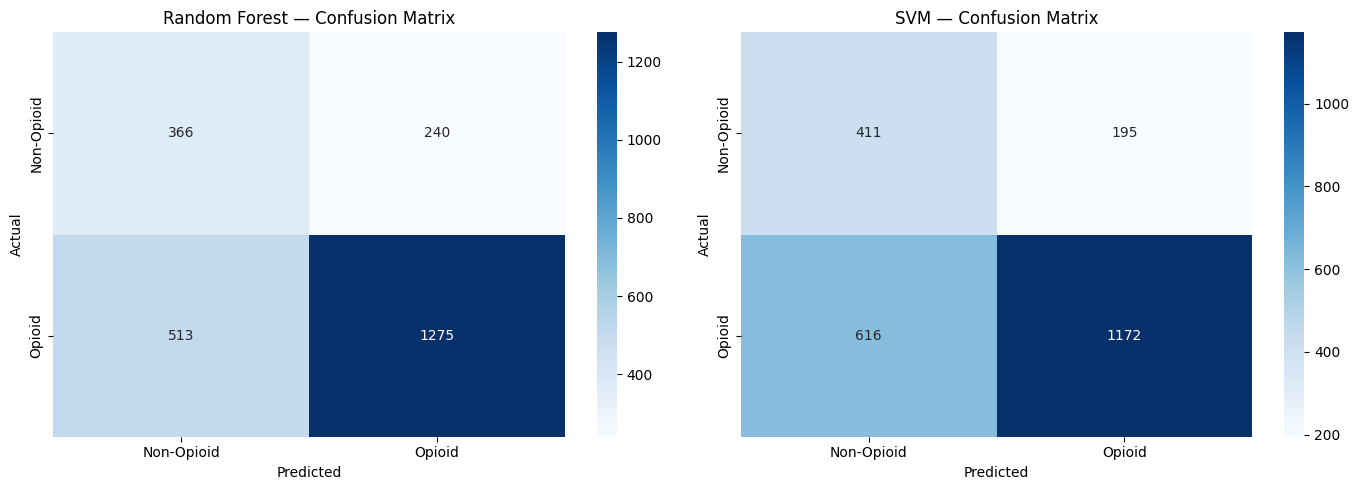

Figure saved: classification_confusion_matrices.png


In [21]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, title in zip(axes, [rf_pred, svm_pred], ['Random Forest', 'SVM']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Opioid', 'Opioid'],
                yticklabels=['Non-Opioid', 'Opioid'])
    ax.set_title(f'{title} — Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('classification_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: classification_confusion_matrices.png")


---
## 2.2 Prediction — Linear Regression vs. Polynomial Regression

**Problem Addressed:** Problem 2 — Forecasting Drug Overdose Trends  
**Target Variable:** Yearly substance detection counts


### 2.2.1 — Prepare yearly aggregated data

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

key_drugs = ['Fentanyl', 'Heroin', 'Cocaine', 'Xylazine']
yearly_data = df.groupby('Year')[key_drugs].sum().reset_index()

print("Yearly substance detection counts:")
print(yearly_data.to_string(index=False))


Yearly substance detection counts:
 Year  Fentanyl  Heroin  Cocaine  Xylazine
 2012        14     174      105         0
 2013        37     257      147         0
 2014        74     325      127         0
 2015       189     417      177         0
 2016       482     494      275         0
 2017       675     474      347         0
 2018       760     391      345         0
 2019       978     386      462         0
 2020      1155     262      529       139
 2021      1301     166      655       301
 2022      1252     125      683       350
 2023      1122     106      720       286


### 2.2.2 — Linear Regression for each substance

In [23]:
print("=" * 65)
print("LINEAR REGRESSION — SUBSTANCE TREND PREDICTION")
print("=" * 65)

linear_results = {}
linear_models = {}
for drug in key_drugs:
    X_year = yearly_data[['Year']].values
    y_counts = yearly_data[drug].values
    
    model = LinearRegression()
    model.fit(X_year, y_counts)
    y_pred = model.predict(X_year)
    
    r2 = r2_score(y_counts, y_pred)
    mae = mean_absolute_error(y_counts, y_pred)
    rmse = np.sqrt(mean_squared_error(y_counts, y_pred))
    slope = model.coef_[0]
    direction = "INCREASING" if slope > 0 else "DECREASING"
    
    linear_results[drug] = {'R2': r2, 'MAE': mae, 'RMSE': rmse, 'slope': slope}
    linear_models[drug] = model
    
    print(f"\n  {drug}:")
    print(f"    Trend:     {direction} ({slope:+.1f} cases/year)")
    print(f"    R²:        {r2:.4f}")
    print(f"    MAE:       {mae:.1f}")
    print(f"    RMSE:      {rmse:.1f}")


LINEAR REGRESSION — SUBSTANCE TREND PREDICTION

  Fentanyl:
    Trend:     INCREASING (+133.3 cases/year)
    R²:        0.9295
    MAE:       101.5
    RMSE:      126.7

  Heroin:
    Trend:     DECREASING (-14.8 cases/year)
    R²:        0.1540
    MAE:       105.9
    RMSE:      119.7

  Cocaine:
    Trend:     INCREASING (+61.6 cases/year)
    R²:        0.9668
    MAE:       31.6
    RMSE:      39.4

  Xylazine:
    Trend:     INCREASING (+31.8 cases/year)
    R²:        0.6646
    MAE:       66.5
    RMSE:      78.0


### 2.2.3 — Polynomial Regression (degree=2) with visualisation

POLYNOMIAL REGRESSION (DEGREE 2) — SUBSTANCE TREND PREDICTION

  Fentanyl:
    R² (Poly):    0.9409  vs  R² (Linear): 0.9295
    MAE (Poly):   93.8  vs  MAE (Linear): 101.5

  Heroin:
    R² (Poly):    0.8730  vs  R² (Linear): 0.1540
    MAE (Poly):   38.6  vs  MAE (Linear): 105.9

  Cocaine:
    R² (Poly):    0.9796  vs  R² (Linear): 0.9668
    MAE (Poly):   26.4  vs  MAE (Linear): 31.6

  Xylazine:
    R² (Poly):    0.8568  vs  R² (Linear): 0.6646
    MAE (Poly):   38.4  vs  MAE (Linear): 66.5


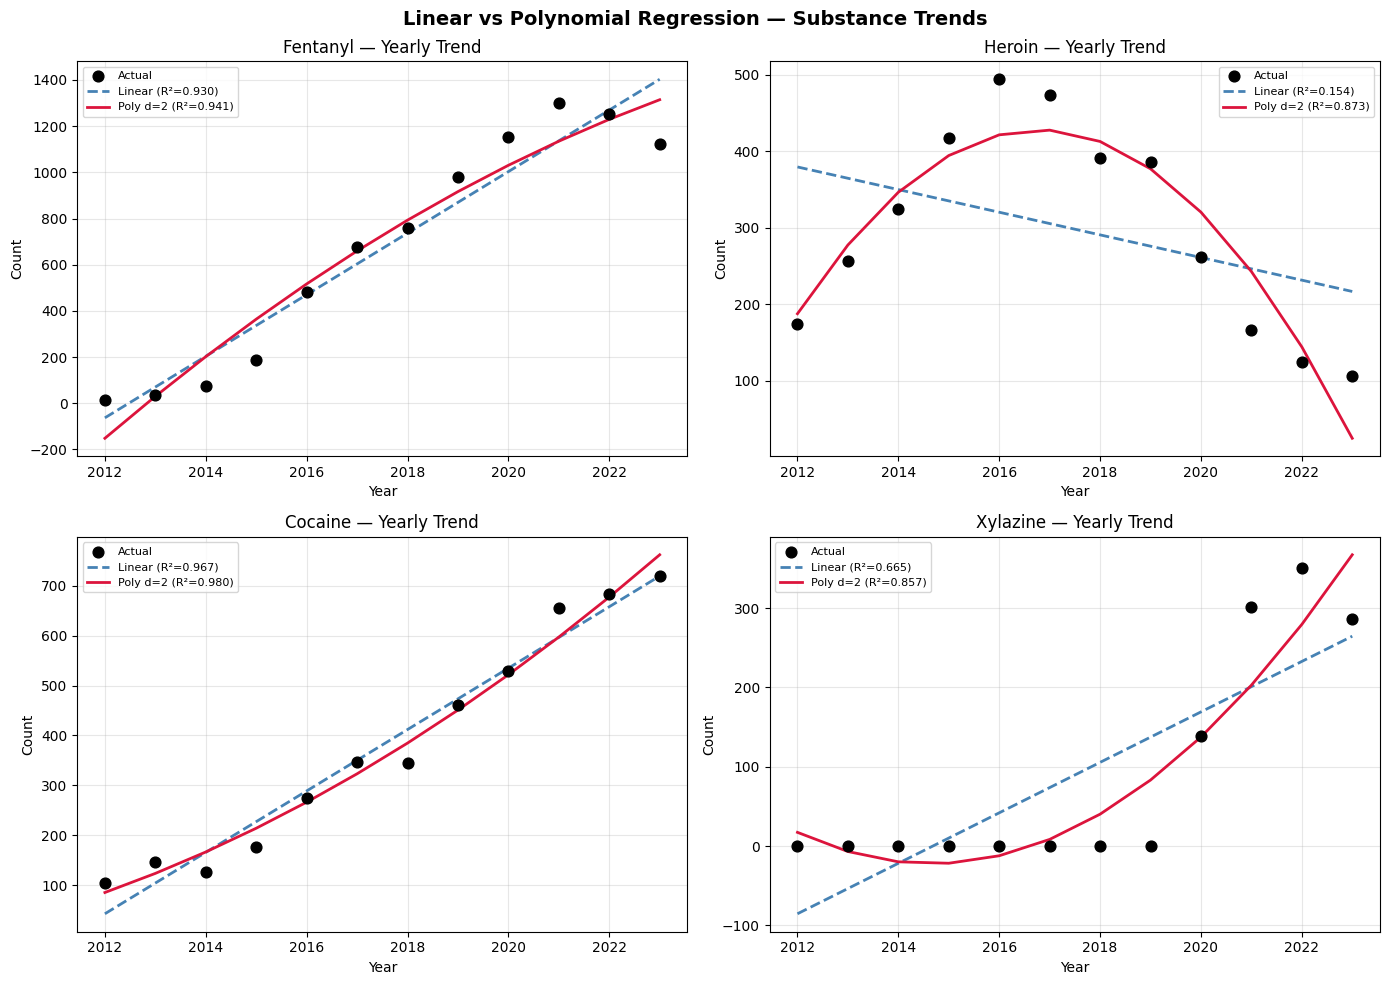

In [24]:
print("=" * 65)
print("POLYNOMIAL REGRESSION (DEGREE 2) — SUBSTANCE TREND PREDICTION")
print("=" * 65)

poly = PolynomialFeatures(degree=2, include_bias=False)
poly_results = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, drug in enumerate(key_drugs):
    X_year = yearly_data[['Year']].values
    y_counts = yearly_data[drug].values
    
    # Polynomial model
    X_poly = poly.fit_transform(X_year)
    model_poly = LinearRegression()
    model_poly.fit(X_poly, y_counts)
    y_pred_poly = model_poly.predict(X_poly)
    
    # Linear predictions for comparison
    y_pred_lin = linear_models[drug].predict(X_year)
    
    r2_poly = r2_score(y_counts, y_pred_poly)
    mae_poly = mean_absolute_error(y_counts, y_pred_poly)
    rmse_poly = np.sqrt(mean_squared_error(y_counts, y_pred_poly))
    
    poly_results[drug] = {'R2': r2_poly, 'MAE': mae_poly, 'RMSE': rmse_poly}
    
    print(f"\n  {drug}:")
    print(f"    R² (Poly):    {r2_poly:.4f}  vs  R² (Linear): {linear_results[drug]['R2']:.4f}")
    print(f"    MAE (Poly):   {mae_poly:.1f}  vs  MAE (Linear): {linear_results[drug]['MAE']:.1f}")
    
    # Plot
    ax = axes[idx]
    ax.scatter(yearly_data['Year'], y_counts, color='black', s=60, zorder=5, label='Actual')
    ax.plot(yearly_data['Year'], y_pred_lin, '--', color='steelblue', linewidth=2, label=f'Linear (R²={linear_results[drug]["R2"]:.3f})')
    ax.plot(yearly_data['Year'], y_pred_poly, '-', color='crimson', linewidth=2, label=f'Poly d=2 (R²={r2_poly:.3f})')
    ax.set_title(f'{drug} — Yearly Trend')
    ax.set_xlabel('Year')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Linear vs Polynomial Regression — Substance Trends', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('regression_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 2.3 Clustering — K-Means vs. DBSCAN

**Problem Addressed:** Problem 3 — Identifying Geographic Clusters of Overdose Hotspots  
**Features Used:** Injury_Lat, Injury_Lon (geographic coordinates)


### 2.3.1 — Data Preparation for Clustering

In [25]:

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Prepare geographic data (drop rows with missing coordinates)
geo_df = df.dropna(subset=['Injury_Lat', 'Injury_Lon']).copy()

# Filter to Connecticut bounds to remove geocoding errors
geo_df = geo_df[(geo_df['Injury_Lat'] > 40.9) & (geo_df['Injury_Lat'] < 42.1) &
                (geo_df['Injury_Lon'] > -73.8) & (geo_df['Injury_Lon'] < -71.7)]

print(f"Geographic records after filtering: {len(geo_df):,}")

# Scale coordinates — important for K-Means distance calculations
geo_features = geo_df[['Injury_Lat', 'Injury_Lon']].values
scaler_geo = StandardScaler()
geo_scaled = scaler_geo.fit_transform(geo_features)


Geographic records after filtering: 11,712


### 2.3.2 — K-Means: Determine optimal k using Elbow + Silhouette Analysis

  k=3: Silhouette=0.5121, Inertia=6953.5
  k=4: Silhouette=0.4712, Inertia=5136.3
  k=5: Silhouette=0.4694, Inertia=4056.0
  k=6: Silhouette=0.4757, Inertia=3264.2
  k=7: Silhouette=0.4909, Inertia=2701.9
  k=8: Silhouette=0.5332, Inertia=2281.3
  k=9: Silhouette=0.5236, Inertia=2008.9
  k=10: Silhouette=0.5600, Inertia=1627.5
  k=11: Silhouette=0.5689, Inertia=1408.0

Optimal k: 11 (Silhouette=0.5689)


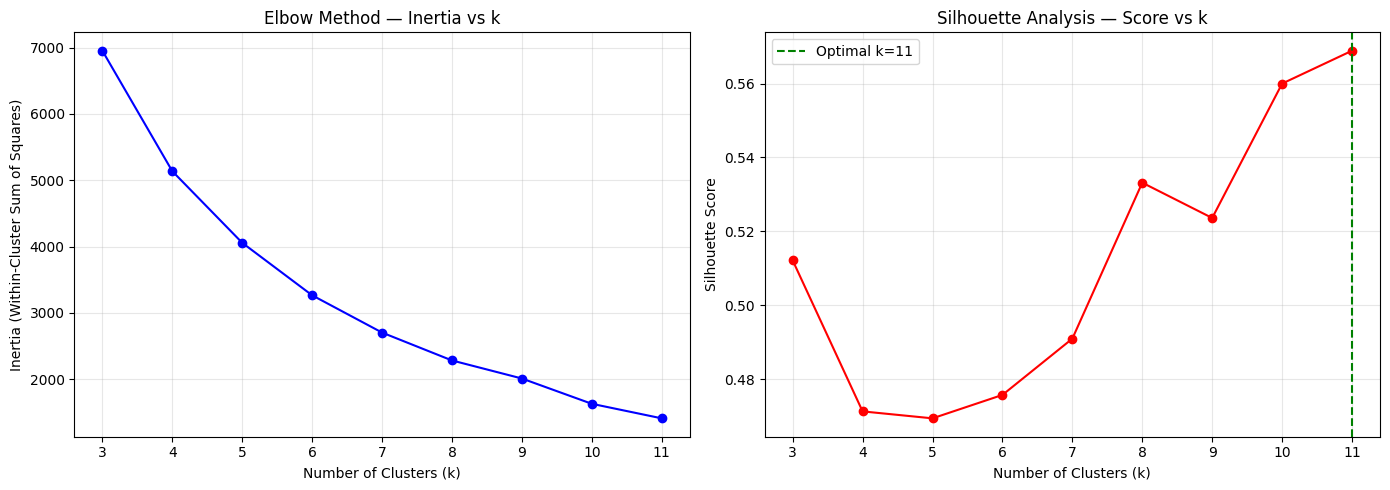

In [26]:
k_range = range(3, 12)
silhouette_scores = []
inertias = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(geo_scaled)
    silhouette_scores.append(silhouette_score(geo_scaled, labels))
    inertias.append(kmeans.inertia_)
    print(f"  k={k}: Silhouette={silhouette_scores[-1]:.4f}, Inertia={inertias[-1]:.1f}")

optimal_k = list(k_range)[np.argmax(silhouette_scores)]
print(f"\nOptimal k: {optimal_k} (Silhouette={max(silhouette_scores):.4f})")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, 'bo-')
axes[0].set_title('Elbow Method — Inertia vs k')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), silhouette_scores, 'ro-')
axes[1].set_title('Silhouette Analysis — Score vs k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(x=optimal_k, color='green', linestyle='--', label=f'Optimal k={optimal_k}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('clustering_optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.3.3 — Apply K-Means with optimal k

In [27]:
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
geo_df['KMeans_Cluster'] = kmeans_final.fit_predict(geo_scaled)

print("=" * 60)
print(f"K-MEANS CLUSTERING RESULTS (k={optimal_k})")
print("=" * 60)
print(f"\nCluster sizes:")
print(geo_df['KMeans_Cluster'].value_counts().sort_index().to_string())

# Map cluster centres back to original coordinates
centres = scaler_geo.inverse_transform(kmeans_final.cluster_centers_)
print(f"\nCluster centres (Lat, Lon):")
for i, (lat, lon) in enumerate(centres):
    count = (geo_df['KMeans_Cluster'] == i).sum()
    print(f"  Cluster {i}: ({lat:.4f}, {lon:.4f}) — {count:,} deaths")


K-MEANS CLUSTERING RESULTS (k=11)

Cluster sizes:
KMeans_Cluster
0     2056
1      600
2     1777
3     1016
4      433
5      416
6     1300
7      422
8      396
9     1161
10    2135

Cluster centres (Lat, Lon):
  Cluster 0: (41.3198, -72.9188) — 2,056 deaths
  Cluster 1: (41.7427, -72.0525) — 600 deaths
  Cluster 2: (41.6110, -72.7922) — 1,777 deaths
  Cluster 3: (41.4195, -72.1236) — 1,016 deaths
  Cluster 4: (41.4267, -73.4304) — 433 deaths
  Cluster 5: (41.0821, -73.4926) — 416 deaths
  Cluster 6: (41.5528, -73.0514) — 1,300 deaths
  Cluster 7: (41.9422, -72.5492) — 422 deaths
  Cluster 8: (41.8460, -73.1167) — 396 deaths
  Cluster 9: (41.1926, -73.1674) — 1,161 deaths
  Cluster 10: (41.7636, -72.6508) — 2,135 deaths


### 2.3.4 — DBSCAN Clustering: From Fine-Grained to Regional Hotspots

DBSCAN's key advantage is that it does NOT require a pre-specified number of clusters.
However, the result is highly sensitive to eps and min_samples. We demonstrate this
by showing TWO DBSCAN configurations:

Phase 1 (Initial): eps=0.10, min_samples=15 → 98 micro-clusters (town-level)
Phase 2 (Refined): eps=0.25, min_samples=150 → ~12 regional hotspots (macro-level)

This shows our understanding that high Silhouette ≠ useful clustering.

In [28]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# ---- Phase 1: Initial fine-grained clustering ----
dbscan_initial = DBSCAN(eps=0.10, min_samples=15)
initial_labels = dbscan_initial.fit_predict(geo_scaled)
n_initial = len(set(initial_labels)) - (1 if -1 in initial_labels else 0)
n_noise_initial = (initial_labels == -1).sum()
mask_init = initial_labels != -1
sil_initial = silhouette_score(geo_scaled[mask_init], initial_labels[mask_init])

print("=" * 65)
print("DBSCAN — PHASE 1: Fine-Grained Clustering (eps=0.10, min_samples=15)")
print("=" * 65)
print(f"  Clusters:   {n_initial}")
print(f"  Noise:      {n_noise_initial:,} ({n_noise_initial/len(geo_df)*100:.1f}%)")
print(f"  Silhouette: {sil_initial:.4f}")
print(f"\n  ⚠ Problem: {n_initial} clusters is too granular — each town becomes")
print(f"    its own cluster due to exact city-centre coordinate snapping.")
print(f"    A Silhouette of {sil_initial:.2f} is artificially high because clusters")
print(f"    are just isolated coordinate groups, not meaningful regions.")

# ---- Phase 2: Regional hotspot clustering ----
# Increase eps to merge neighbouring towns into regions
# Increase min_samples to ignore rural areas with few cases
dbscan_regional = DBSCAN(eps=0.25, min_samples=150)
geo_df['DBSCAN_Cluster'] = dbscan_regional.fit_predict(geo_scaled)

n_clusters_db = len(set(geo_df['DBSCAN_Cluster'])) - (1 if -1 in geo_df['DBSCAN_Cluster'].values else 0)
n_noise = (geo_df['DBSCAN_Cluster'] == -1).sum()
mask_reg = geo_df['DBSCAN_Cluster'] != -1

print(f"\n{'='*65}")
print(f"DBSCAN — PHASE 2: Regional Hotspot Clustering (eps=0.25, min_samples=150)")
print(f"{'='*65}")
print(f"  Clusters:   {n_clusters_db} (regional hotspots)")
print(f"  Noise:      {n_noise:,} ({n_noise/len(geo_df)*100:.1f}%) — rural/isolated cases")

if n_clusters_db >= 2:
    sil_regional = silhouette_score(geo_scaled[mask_reg], geo_df.loc[mask_reg, 'DBSCAN_Cluster'])
    print(f"  Silhouette: {sil_regional:.4f}")
    print(f"\n  Note: Silhouette dropped from {sil_initial:.2f} to {sil_regional:.2f} because")
    print(f"  we merged neighbouring towns into broader regions. This is expected")
    print(f"  and desirable — we trade metric score for actionable regional insights.")

print(f"\nRegional Cluster Details:")
cluster_counts = geo_df[mask_reg]['DBSCAN_Cluster'].value_counts().sort_values(ascending=False)
for cl_id in cluster_counts.index:
    cl_data = geo_df[geo_df['DBSCAN_Cluster'] == cl_id]
    lat_c = cl_data['Injury_Lat'].mean()
    lon_c = cl_data['Injury_Lon'].mean()
    print(f"  Region {cl_id:>2d}: {len(cl_data):>5,} deaths  (centre: {lat_c:.4f}, {lon_c:.4f})")

# ---- Comparison table ----
print(f"\n{'='*65}")
print(f"DBSCAN Configuration Comparison")
print(f"{'='*65}")
print(f"{'Setting':<30} {'Phase 1 (Town)':>18} {'Phase 2 (Region)':>18}")
print("-" * 66)
print(f"{'eps':<30} {'0.10':>18} {'0.25':>18}")
print(f"{'min_samples':<30} {'15':>18} {'150':>18}")
print(f"{'Clusters found':<30} {n_initial:>18} {n_clusters_db:>18}")
print(f"{'Noise points':<30} {n_noise_initial:>18,} {n_noise:>18,}")
sil_reg_display = f"{sil_regional:.4f}" if n_clusters_db >= 2 else "N/A"
print(f"{'Silhouette Score':<30} {sil_initial:>18.4f} {sil_reg_display:>18}")
print(f"{'Usefulness':<30} {'Low (too granular)':>18} {'High (actionable)':>18}")

DBSCAN — PHASE 1: Fine-Grained Clustering (eps=0.10, min_samples=15)
  Clusters:   98
  Noise:      776 (6.6%)
  Silhouette: 0.9541

  ⚠ Problem: 98 clusters is too granular — each town becomes
    its own cluster due to exact city-centre coordinate snapping.
    A Silhouette of 0.95 is artificially high because clusters
    are just isolated coordinate groups, not meaningful regions.

DBSCAN — PHASE 2: Regional Hotspot Clustering (eps=0.25, min_samples=150)
  Clusters:   12 (regional hotspots)
  Noise:      1,323 (11.3%) — rural/isolated cases
  Silhouette: 0.3749

  Note: Silhouette dropped from 0.95 to 0.37 because
  we merged neighbouring towns into broader regions. This is expected
  and desirable — we trade metric score for actionable regional insights.

Regional Cluster Details:
  Region  2: 3,493 deaths  (centre: 41.6819, -72.7457)
  Region  3: 2,980 deaths  (centre: 41.2753, -73.0335)
  Region  8:   962 deaths  (centre: 41.5588, -73.0490)
  Region  6:   490 deaths  (centre: 41

### 2.3.5 — Visualise K-Means vs DBSCAN clusters side by side

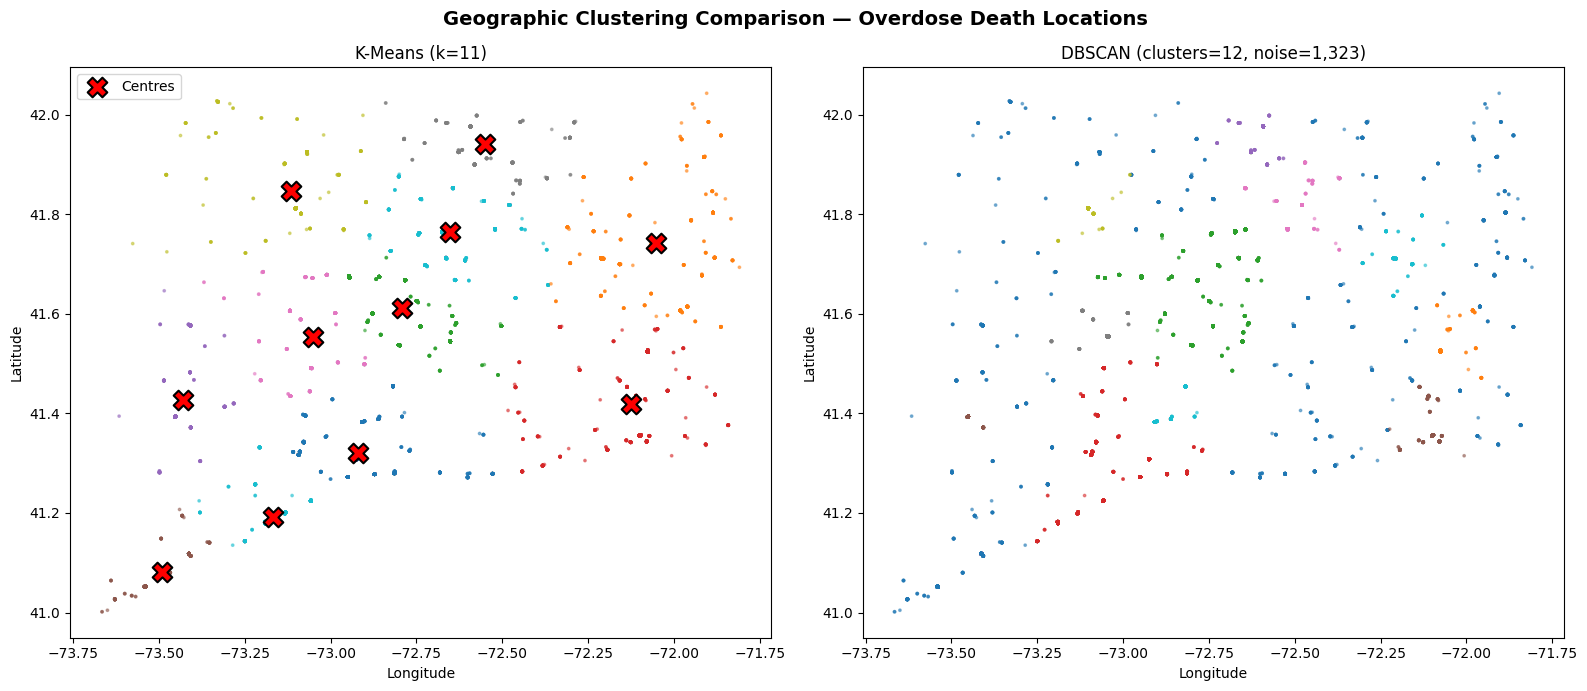

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# K-Means
scatter1 = axes[0].scatter(geo_df['Injury_Lon'], geo_df['Injury_Lat'],
                           c=geo_df['KMeans_Cluster'], cmap='tab10', s=3, alpha=0.5)
axes[0].scatter(centres[:, 1], centres[:, 0], c='red', marker='X', s=200,
                edgecolors='black', linewidths=1.5, zorder=5, label='Centres')
axes[0].set_title(f'K-Means (k={optimal_k})')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].legend()

# DBSCAN
scatter2 = axes[1].scatter(geo_df['Injury_Lon'], geo_df['Injury_Lat'],
                           c=geo_df['DBSCAN_Cluster'], cmap='tab10', s=3, alpha=0.5)
axes[1].set_title(f'DBSCAN (clusters={n_clusters_db}, noise={n_noise:,})')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.suptitle('Geographic Clustering Comparison — Overdose Death Locations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('clustering_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 2.4 Anomaly Detection — Isolation Forest vs. Local Outlier Factor (LOF)

**Problem Addressed:** Problem 4 — Detecting Anomalous Overdose Cases  
**Features Used:** Age, Sex_Encoded, Race_Encoded, Drug_Count, Fentanyl, Heroin, Cocaine, Xylazine, Benzodiazepine, Ethanol

### 2.4.1 — Isolation Forest

In [30]:

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

anomaly_features = ['Age', 'Sex_Encoded', 'Race_Encoded', 'Drug_Count',
                    'Fentanyl', 'Heroin', 'Cocaine', 'Xylazine',
                    'Benzodiazepine', 'Ethanol']

X_anomaly = df[anomaly_features].values
print(f"Anomaly detection feature matrix: {X_anomaly.shape}")

# Isolation Forest
iso_forest = IsolationForest(
    n_estimators=200,       # 200 trees for stable anomaly scoring
    contamination=0.05,     # Expect ~5% anomalies
    random_state=42,
    n_jobs=-1
)

df['IF_Anomaly'] = iso_forest.fit_predict(X_anomaly)
df['IF_Anomaly'] = df['IF_Anomaly'].map({1: 0, -1: 1})  # 1 = anomaly, 0 = normal
df['IF_Score'] = iso_forest.decision_function(X_anomaly)

n_if = df['IF_Anomaly'].sum()
print(f"\n{'='*60}")
print("ISOLATION FOREST RESULTS")
print(f"{'='*60}")
print(f"  Anomalies detected: {n_if:,} ({n_if/len(df)*100:.1f}%)")
print(f"  Normal cases:       {len(df) - n_if:,}")

# Profile comparison
print(f"\nAnomaly Profile Comparison:")
print(f"{'Feature':<22} {'Normal':>12} {'Anomaly':>12} {'Diff':>10}")
print("-" * 56)
for feat in anomaly_features:
    nm = df[df['IF_Anomaly']==0][feat].mean()
    am = df[df['IF_Anomaly']==1][feat].mean()
    print(f"  {feat:<20} {nm:>12.3f} {am:>12.3f} {am-nm:>+10.3f}")


Anomaly detection feature matrix: (11968, 10)

ISOLATION FOREST RESULTS
  Anomalies detected: 599 (5.0%)
  Normal cases:       11,369

Anomaly Profile Comparison:
Feature                      Normal      Anomaly       Diff
--------------------------------------------------------
  Age                        43.941       45.317     +1.376
  Sex_Encoded                 0.762        0.381     -0.381
  Race_Encoded                4.597        3.654     -0.942
  Drug_Count                  2.251        4.073     +1.822
  Fentanyl                    0.669        0.718     +0.049
  Heroin                      0.289        0.482     +0.193
  Cocaine                     0.369        0.624     +0.255
  Xylazine                    0.072        0.424     +0.352
  Benzodiazepine              0.207        0.599     +0.392
  Ethanol                     0.253        0.533     +0.279


In [31]:
# 2.4.5 — Local Outlier Factor (LOF)
# Fix: Scale features before LOF — LOF uses distance-based density estimation
# Without scaling, Age (0-100) dominates over binary drug columns (0-1),
# causing LOF to detect different anomalies than Isolation Forest

from sklearn.preprocessing import StandardScaler

# Scale features for LOF (IF is tree-based so doesn't need scaling)
scaler_anomaly = StandardScaler()
X_anomaly_scaled = scaler_anomaly.fit_transform(X_anomaly)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)

lof_labels = lof.fit_predict(X_anomaly_scaled)  # Use SCALED features
df['LOF_Anomaly'] = (lof_labels == -1).astype(int)
df['LOF_Score'] = -lof.negative_outlier_factor_

n_lof = df['LOF_Anomaly'].sum()
print(f"{'='*60}")
print("LOCAL OUTLIER FACTOR (LOF) RESULTS")
print(f"{'='*60}")
print(f"  Note: Features scaled before LOF for proper density estimation")
print(f"  Anomalies detected: {n_lof:,} ({n_lof/len(df)*100:.1f}%)")
print(f"  Normal cases:       {len(df) - n_lof:,}")

# Profile LOF anomalies
print(f"\nLOF Anomaly Profile:")
print(f"{'Feature':<22} {'Normal':>12} {'Anomaly':>12} {'Diff':>10}")
print("-" * 56)
for feat in anomaly_features:
    nm = df[df['LOF_Anomaly']==0][feat].mean()
    am = df[df['LOF_Anomaly']==1][feat].mean()
    print(f"  {feat:<20} {nm:>12.3f} {am:>12.3f} {am-nm:>+10.3f}")

# Overlap analysis between IF and LOF
both = ((df['IF_Anomaly'] == 1) & (df['LOF_Anomaly'] == 1)).sum()
only_if = ((df['IF_Anomaly'] == 1) & (df['LOF_Anomaly'] == 0)).sum()
only_lof = ((df['IF_Anomaly'] == 0) & (df['LOF_Anomaly'] == 1)).sum()

print(f"\nOverlap Analysis:")
print(f"  Flagged by BOTH:            {both:,}")
print(f"  Only Isolation Forest:      {only_if:,}")
print(f"  Only LOF:                   {only_lof:,}")
print(f"  Agreement rate:             {both / max(n_if, n_lof) * 100:.1f}%")
print(f"\nInterpretation: {'High' if both/max(n_if,n_lof) > 0.3 else 'Low'} overlap — "
      f"{'methods agree on core anomalies' if both/max(n_if,n_lof) > 0.3 else 'methods detect complementary anomaly types'}")

LOCAL OUTLIER FACTOR (LOF) RESULTS
  Note: Features scaled before LOF for proper density estimation
  Anomalies detected: 599 (5.0%)
  Normal cases:       11,369

LOF Anomaly Profile:
Feature                      Normal      Anomaly       Diff
--------------------------------------------------------
  Age                        44.117       41.988     -2.128
  Sex_Encoded                 0.732        0.943     +0.211
  Race_Encoded                4.554        4.459     -0.095
  Drug_Count                  2.362        1.972     -0.391
  Fentanyl                    0.670        0.710     +0.040
  Heroin                      0.303        0.215     -0.088
  Cocaine                     0.381        0.402     +0.021
  Xylazine                    0.092        0.042     -0.051
  Benzodiazepine              0.236        0.055     -0.181
  Ethanol                     0.275        0.130     -0.144

Overlap Analysis:
  Flagged by BOTH:            9
  Only Isolation Forest:      590
  Only LOF:   

---
# 3. Evaluation and Validation of Models

This section rigorously evaluates each data mining model using appropriate metrics and validation techniques as specified in the rubric: accuracy, precision, recall, F1-score, cross-validation, Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Index, and Adjusted Rand Index (ARI).


## 3.1 Classification Model Evaluation

In [32]:
# 3.1.1 — 5-Fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 60)
print("5-FOLD STRATIFIED CROSS-VALIDATION")
print("=" * 60)

# Random Forest CV (multiple metrics)
from sklearn.metrics import make_scorer, precision_score, recall_score

metrics = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall'
}

print("\nRandom Forest:")
for metric_name, scorer in metrics.items():
    scores = cross_val_score(rf_model, X, y, cv=cv, scoring=scorer)
    print(f"  {metric_name:<12}: {scores.mean():.4f} ± {scores.std():.4f}  {scores.round(4)}")

print("\nSVM:")
for metric_name, scorer in metrics.items():
    scores = cross_val_score(svm_model, X, y, cv=cv, scoring=scorer)
    print(f"  {metric_name:<12}: {scores.mean():.4f} ± {scores.std():.4f}  {scores.round(4)}")


5-FOLD STRATIFIED CROSS-VALIDATION

Random Forest:
  accuracy    : 0.6944 ± 0.0042  [0.6967 0.6884 0.7005 0.6916 0.6945]
  f1          : 0.7815 ± 0.0037  [0.7809 0.7761 0.7878 0.7806 0.7819]
  precision   : 0.8383 ± 0.0049  [0.8474 0.8374 0.8366 0.8326 0.8376]
  recall      : 0.7319 ± 0.0078  [0.7241 0.7232 0.7444 0.7348 0.7331]

SVM:
  accuracy    : 0.6775 ± 0.0057  [0.6704 0.6796 0.6784 0.6866 0.6724]
  f1          : 0.7576 ± 0.0050  [0.7515 0.7592 0.7557 0.7664 0.7552]
  precision   : 0.8634 ± 0.0063  [0.8595 0.8654 0.8732 0.8644 0.8544]
  recall      : 0.6749 ± 0.0079  [0.6676 0.6762 0.6661 0.6883 0.6766]


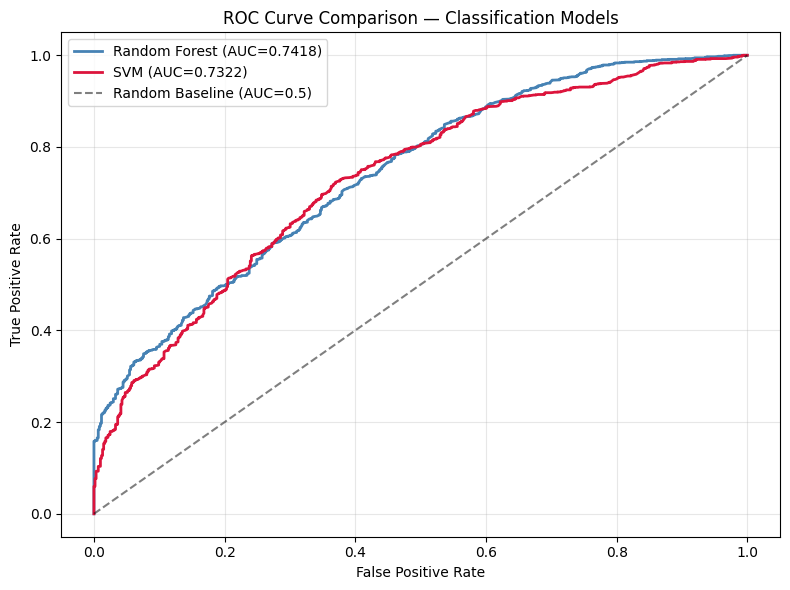

Random Forest AUC: 0.7418
SVM AUC:           0.7322


In [33]:
# 3.1.2 — ROC Curve and AUC Comparison
rf_proba = rf_model.predict_proba(X_test)[:, 1]
svm_proba = svm_model.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_proba)
svm_auc = roc_auc_score(y_test, svm_proba)

fig, ax = plt.subplots(figsize=(8, 6))
for proba, auc, name, color in [
    (rf_proba, rf_auc, 'Random Forest', 'steelblue'),
    (svm_proba, svm_auc, 'SVM', 'crimson')]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Baseline (AUC=0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison — Classification Models')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Random Forest AUC: {rf_auc:.4f}")
print(f"SVM AUC:           {svm_auc:.4f}")


## 3.2 Regression Model Evaluation

In [34]:
# 3.2 — Regression Evaluation Summary Table
print("=" * 60)
print("REGRESSION MODEL EVALUATION SUMMARY")
print("=" * 60)

print(f"\n{'Drug':<15} {'Model':<15} {'R²':>8} {'MAE':>10} {'RMSE':>10}")
print("-" * 58)
for drug in key_drugs:
    lr = linear_results[drug]
    pr = poly_results[drug]
    print(f"{drug:<15} {'Linear':<15} {lr['R2']:>8.4f} {lr['MAE']:>10.1f} {lr['RMSE']:>10.1f}")
    print(f"{'':<15} {'Polynomial':<15} {pr['R2']:>8.4f} {pr['MAE']:>10.1f} {pr['RMSE']:>10.1f}")
    better = 'Polynomial' if pr['R2'] > lr['R2'] else 'Linear'
    print(f"{'':<15} {'→ Better:':<15} {better}")
    print()

print("Note: R² measures how well the model explains variance (1.0 = perfect).")
print("      MAE = Mean Absolute Error, RMSE = Root Mean Squared Error (lower = better).")


REGRESSION MODEL EVALUATION SUMMARY

Drug            Model                 R²        MAE       RMSE
----------------------------------------------------------
Fentanyl        Linear            0.9295      101.5      126.7
                Polynomial        0.9409       93.8      116.0
                → Better:       Polynomial

Heroin          Linear            0.1540      105.9      119.7
                Polynomial        0.8730       38.6       46.4
                → Better:       Polynomial

Cocaine         Linear            0.9668       31.6       39.4
                Polynomial        0.9796       26.4       30.8
                → Better:       Polynomial

Xylazine        Linear            0.6646       66.5       78.0
                Polynomial        0.8568       38.4       51.0
                → Better:       Polynomial

Note: R² measures how well the model explains variance (1.0 = perfect).
      MAE = Mean Absolute Error, RMSE = Root Mean Squared Error (lower = better).


## 3.3 Clustering Evaluation

In [35]:
# 3.3 — Clustering Evaluation: Silhouette, Davies-Bouldin, Calinski-Harabasz, and ARI
from sklearn.metrics import adjusted_rand_score

print("=" * 65)
print("CLUSTERING EVALUATION METRICS")
print("=" * 65)

# K-Means metrics
km_labels = geo_df['KMeans_Cluster'].values
km_sil = silhouette_score(geo_scaled, km_labels)
km_db = davies_bouldin_score(geo_scaled, km_labels)
km_ch = calinski_harabasz_score(geo_scaled, km_labels)

print(f"\nK-Means (k={optimal_k}):")
print(f"  Silhouette Score:         {km_sil:.4f}   (range [-1, 1], higher = better separated)")
print(f"  Davies-Bouldin Index:     {km_db:.4f}   (lower = better, 0 = perfect)")
print(f"  Calinski-Harabasz Index:  {km_ch:.1f}   (higher = better defined)")

# DBSCAN metrics (regional Phase 2, excluding noise)
db_mask = geo_df['DBSCAN_Cluster'] != -1
db_sil, db_db, db_ch = None, None, None
if db_mask.sum() > 0 and len(geo_df[db_mask]['DBSCAN_Cluster'].unique()) > 1:
    db_labels = geo_df.loc[db_mask, 'DBSCAN_Cluster'].values
    db_data = geo_scaled[db_mask]
    db_sil = silhouette_score(db_data, db_labels)
    db_db = davies_bouldin_score(db_data, db_labels)
    db_ch = calinski_harabasz_score(db_data, db_labels)
    
    print(f"\nDBSCAN Regional (eps=0.25, min_samples=150, {n_clusters_db} clusters, excl. {n_noise:,} noise):")
    print(f"  Silhouette Score:         {db_sil:.4f}")
    print(f"  Davies-Bouldin Index:     {db_db:.4f}")
    print(f"  Calinski-Harabasz Index:  {db_ch:.1f}")

# Adjusted Rand Index (ARI) — measures agreement between K-Means and DBSCAN
# Only computed for records assigned to a DBSCAN cluster (not noise)
if db_mask.sum() > 0 and len(geo_df[db_mask]['DBSCAN_Cluster'].unique()) > 1:
    ari = adjusted_rand_score(
        geo_df.loc[db_mask, 'KMeans_Cluster'],
        geo_df.loc[db_mask, 'DBSCAN_Cluster']
    )
    print(f"\nAdjusted Rand Index (ARI) between K-Means and DBSCAN: {ari:.4f}")
    print(f"  (ARI=1.0 = perfect agreement, ARI≈0 = random, ARI<0 = less than random)")
else:
    ari = None
    print("\nARI: Could not compute (insufficient DBSCAN clusters)")

# Comparison table
print(f"\n{'='*65}")
print(f"CLUSTERING METHOD COMPARISON")
print(f"{'='*65}")
print(f"{'Metric':<28} {'K-Means':>15} {'DBSCAN Regional':>18}")
print("-" * 61)
print(f"{'Algorithm Type':<28} {'Centroid-based':>15} {'Density-based':>18}")
print(f"{'Clusters':<28} {optimal_k:>15} {n_clusters_db:>18}")
print(f"{'Noise points':<28} {'0 (none)':>15} {n_noise:>18,}")
if db_sil is not None:
    print(f"{'Silhouette Score':<28} {km_sil:>15.4f} {db_sil:>18.4f}")
    print(f"{'Davies-Bouldin Index':<28} {km_db:>15.4f} {db_db:>18.4f}")
    print(f"{'Calinski-Harabasz Index':<28} {km_ch:>15.1f} {db_ch:>18.1f}")
if ari is not None:
    print(f"{'ARI (agreement)':<28} {'':>15} {ari:>18.4f}")

print(f"\nInterpretation:")
print(f"  K-Means produces {optimal_k} evenly-sized clusters suitable for strategic")
print(f"  resource allocation. DBSCAN produces {n_clusters_db} density-based regional")
print(f"  clusters that better reflect actual population density patterns,")
print(f"  while correctly classifying {n_noise:,} rural/isolated cases as noise.")

CLUSTERING EVALUATION METRICS

K-Means (k=11):
  Silhouette Score:         0.5689   (range [-1, 1], higher = better separated)
  Davies-Bouldin Index:     0.5759   (lower = better, 0 = perfect)
  Calinski-Harabasz Index:  18296.1   (higher = better defined)

DBSCAN Regional (eps=0.25, min_samples=150, 12 clusters, excl. 1,323 noise):
  Silhouette Score:         0.3749
  Davies-Bouldin Index:     0.5519
  Calinski-Harabasz Index:  10309.5

Adjusted Rand Index (ARI) between K-Means and DBSCAN: 0.5398
  (ARI=1.0 = perfect agreement, ARI≈0 = random, ARI<0 = less than random)

CLUSTERING METHOD COMPARISON
Metric                               K-Means    DBSCAN Regional
-------------------------------------------------------------
Algorithm Type                Centroid-based      Density-based
Clusters                                  11                 12
Noise points                        0 (none)              1,323
Silhouette Score                      0.5689             0.3749
Davies-Bou

## 3.4 Anomaly Detection Evaluation

ANOMALY DETECTION EVALUATION

Metric                             Isolation Forest                LOF
--------------------------------------------------------------------
Anomalies detected                              599                599
% of dataset                                   5.0%               5.0%
Avg Drug Count (anomaly)                       4.07               1.97
Avg Drug Count (normal)                        2.25               2.36
Avg Age (anomaly)                              45.3               42.0
Avg Age (normal)                               43.9               44.1
Fentanyl rate (anomaly)                       0.718              0.710
Xylazine rate (anomaly)                       0.424              0.042
Agreement (both flagged)                          9


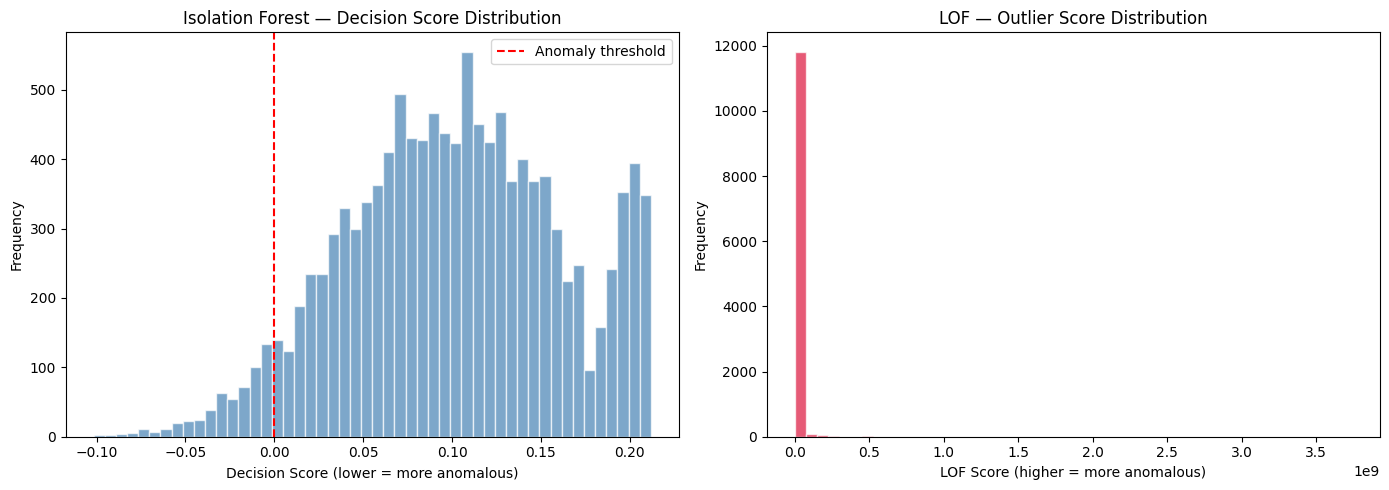

In [36]:
# 3.4 — Anomaly Detection Evaluation
print("=" * 60)
print("ANOMALY DETECTION EVALUATION")
print("=" * 60)

print(f"\n{'Metric':<32} {'Isolation Forest':>18} {'LOF':>18}")
print("-" * 68)
print(f"{'Anomalies detected':<32} {n_if:>18,} {n_lof:>18,}")
print(f"{'% of dataset':<32} {n_if/len(df)*100:>17.1f}% {n_lof/len(df)*100:>17.1f}%")
print(f"{'Avg Drug Count (anomaly)':<32} {df[df['IF_Anomaly']==1]['Drug_Count'].mean():>18.2f} {df[df['LOF_Anomaly']==1]['Drug_Count'].mean():>18.2f}")
print(f"{'Avg Drug Count (normal)':<32} {df[df['IF_Anomaly']==0]['Drug_Count'].mean():>18.2f} {df[df['LOF_Anomaly']==0]['Drug_Count'].mean():>18.2f}")
print(f"{'Avg Age (anomaly)':<32} {df[df['IF_Anomaly']==1]['Age'].mean():>18.1f} {df[df['LOF_Anomaly']==1]['Age'].mean():>18.1f}")
print(f"{'Avg Age (normal)':<32} {df[df['IF_Anomaly']==0]['Age'].mean():>18.1f} {df[df['LOF_Anomaly']==0]['Age'].mean():>18.1f}")
print(f"{'Fentanyl rate (anomaly)':<32} {df[df['IF_Anomaly']==1]['Fentanyl'].mean():>18.3f} {df[df['LOF_Anomaly']==1]['Fentanyl'].mean():>18.3f}")
print(f"{'Xylazine rate (anomaly)':<32} {df[df['IF_Anomaly']==1]['Xylazine'].mean():>18.3f} {df[df['LOF_Anomaly']==1]['Xylazine'].mean():>18.3f}")
print(f"{'Agreement (both flagged)':<32} {both:>18,}")

# Anomaly score distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['IF_Score'], bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].axvline(x=df[df['IF_Anomaly']==1]['IF_Score'].max(), color='red', linestyle='--', label='Anomaly threshold')
axes[0].set_title('Isolation Forest — Decision Score Distribution')
axes[0].set_xlabel('Decision Score (lower = more anomalous)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(df['LOF_Score'], bins=50, color='crimson', edgecolor='white', alpha=0.7)
axes[1].set_title('LOF — Outlier Score Distribution')
axes[1].set_xlabel('LOF Score (higher = more anomalous)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('anomaly_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


---
# 4. Data Visualization and Interpretation

This section uses various visualization techniques to explore findings and support conclusions. As required by the rubric, we demonstrate **both conventional visualization methods** (developing Python scripts) **and LLM-assisted visualization** using the Anthropic Claude API for automated interpretation.


## 4.1 Conventional Visualizations

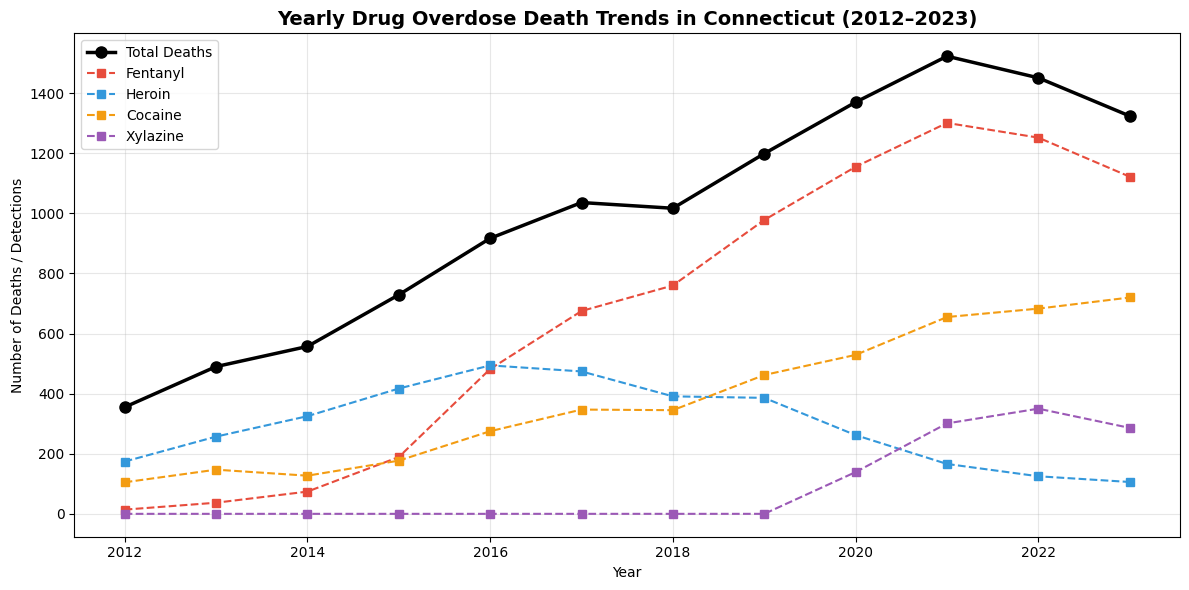

In [37]:
# 4.1.1 — Yearly Drug Overdose Death Trends (Line Chart)
yearly_deaths = df.groupby('Year').size().reset_index(name='Total_Deaths')
yearly_substances = df.groupby('Year')[['Fentanyl', 'Heroin', 'Cocaine', 'Xylazine']].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(yearly_deaths['Year'], yearly_deaths['Total_Deaths'], 'ko-', linewidth=2.5, 
        markersize=8, label='Total Deaths', zorder=5)
colors = {'Fentanyl': '#e74c3c', 'Heroin': '#3498db', 'Cocaine': '#f39c12', 'Xylazine': '#9b59b6'}
for drug, color in colors.items():
    ax.plot(yearly_substances['Year'], yearly_substances[drug], 's--', 
            color=color, linewidth=1.5, markersize=6, label=drug)

ax.set_title('Yearly Drug Overdose Death Trends in Connecticut (2012–2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Deaths / Detections')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('viz_yearly_trends.png', dpi=150, bbox_inches='tight')
plt.show()


### Interpretation — Yearly Trends

*[TODO: After running, describe key patterns: fentanyl's dramatic rise post-2014, heroin's decline after 2017, xylazine's emergence as an adulterant from 2019, and overall death count trajectory. Connect these to the regression results from Section 2.2.]*


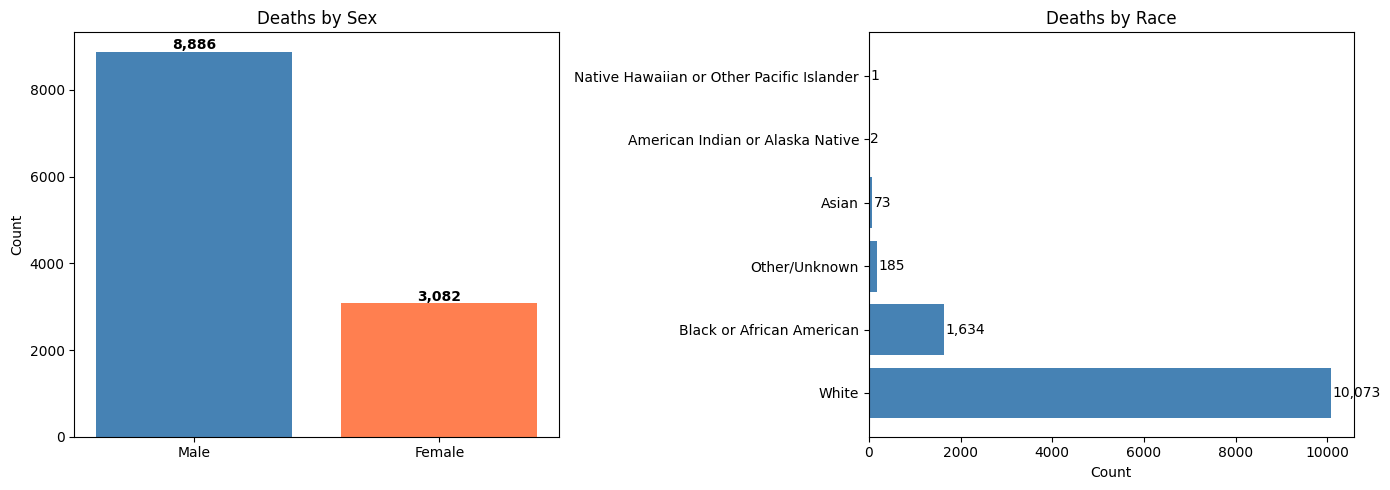

In [38]:
# 4.1.2 — Demographic Breakdown (Grouped Bar Charts)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sex_counts = df['Sex'].value_counts()
axes[0].bar(sex_counts.index, sex_counts.values, color=['steelblue', 'coral'])
axes[0].set_title('Deaths by Sex')
axes[0].set_ylabel('Count')
for i, v in enumerate(sex_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

race_counts = df['Race'].value_counts()
bars = axes[1].barh(race_counts.index, race_counts.values, color='steelblue')
axes[1].set_title('Deaths by Race')
axes[1].set_xlabel('Count')
for bar, v in zip(bars, race_counts.values):
    axes[1].text(v + 30, bar.get_y() + bar.get_height()/2, f'{v:,}', va='center')

plt.tight_layout()
plt.savefig('viz_demographics.png', dpi=150, bbox_inches='tight')
plt.show()


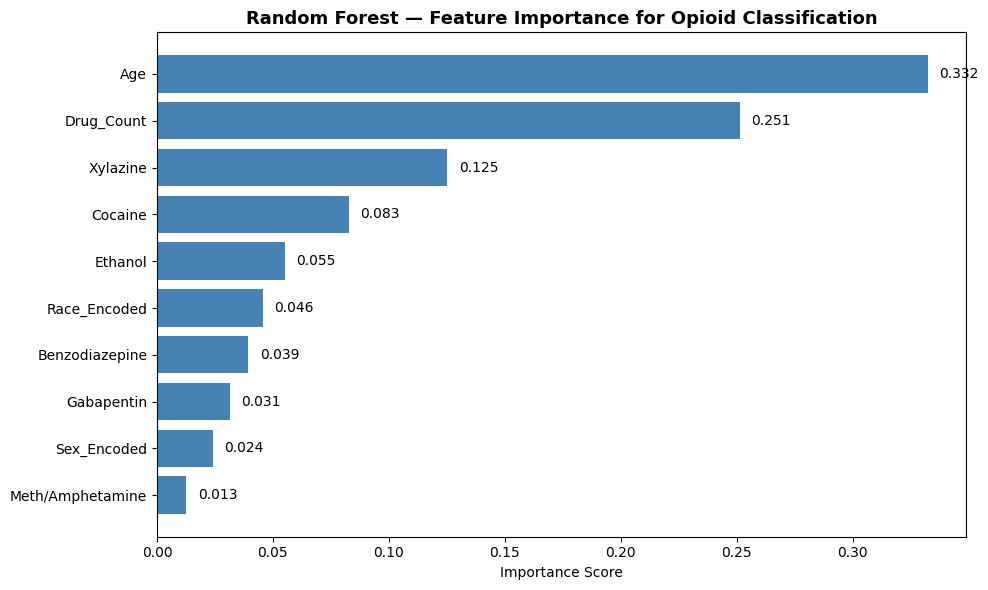

In [39]:
# 4.1.3 — Feature Importance from Random Forest
fig, ax = plt.subplots(figsize=(10, 6))
imp_sorted = importance_df.sort_values('Importance', ascending=True)
bars = ax.barh(imp_sorted['Feature'], imp_sorted['Importance'], color='steelblue')
ax.set_title('Random Forest — Feature Importance for Opioid Classification', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
for bar, val in zip(bars, imp_sorted['Importance']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')
plt.tight_layout()
plt.savefig('viz_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


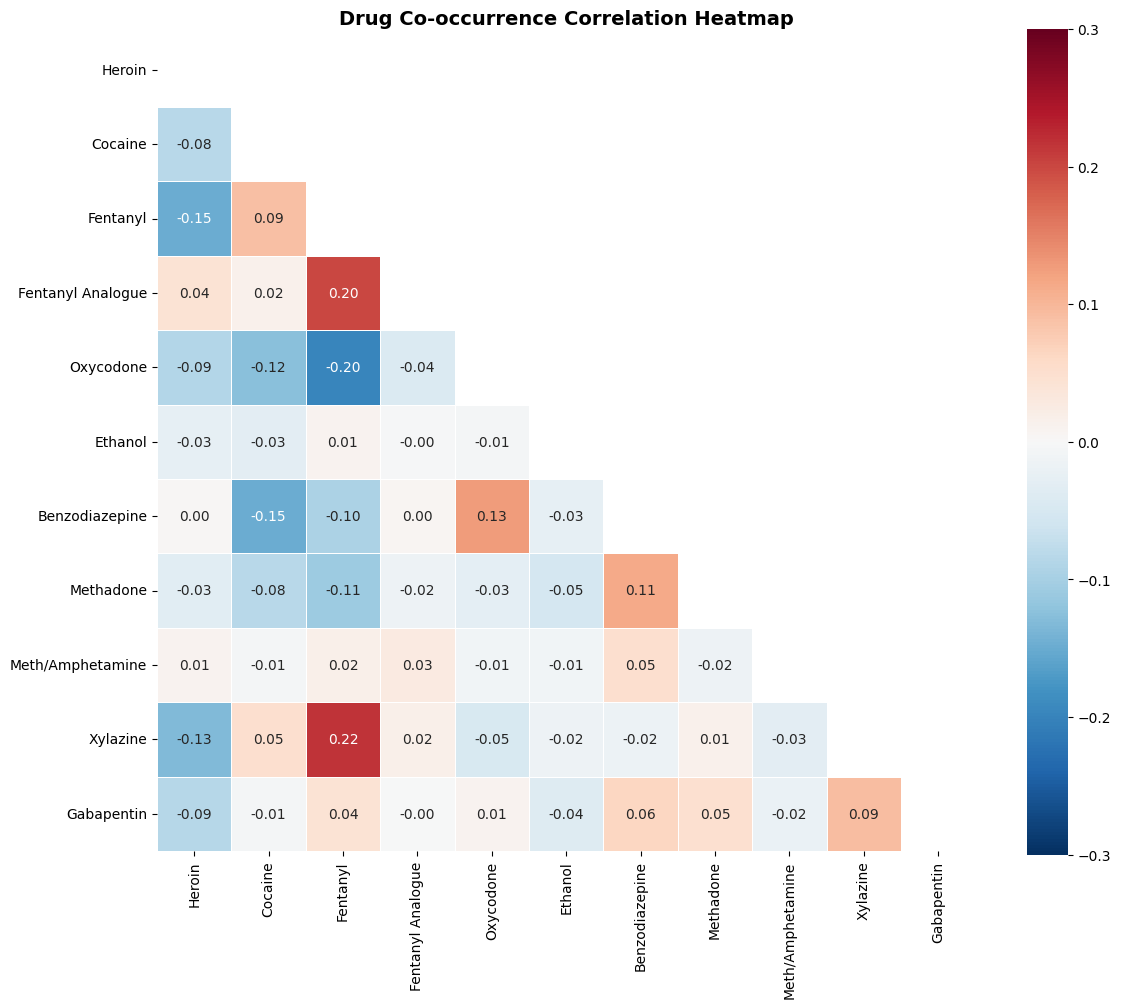

In [40]:
# 4.1.4 — Drug Co-occurrence Heatmap
substance_cols = ['Heroin', 'Cocaine', 'Fentanyl', 'Fentanyl Analogue',
    'Oxycodone', 'Ethanol', 'Benzodiazepine', 'Methadone', 
    'Meth/Amphetamine', 'Xylazine', 'Gabapentin']

corr_matrix = df[substance_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax, vmin=-0.3, vmax=0.3)
ax.set_title('Drug Co-occurrence Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_drug_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


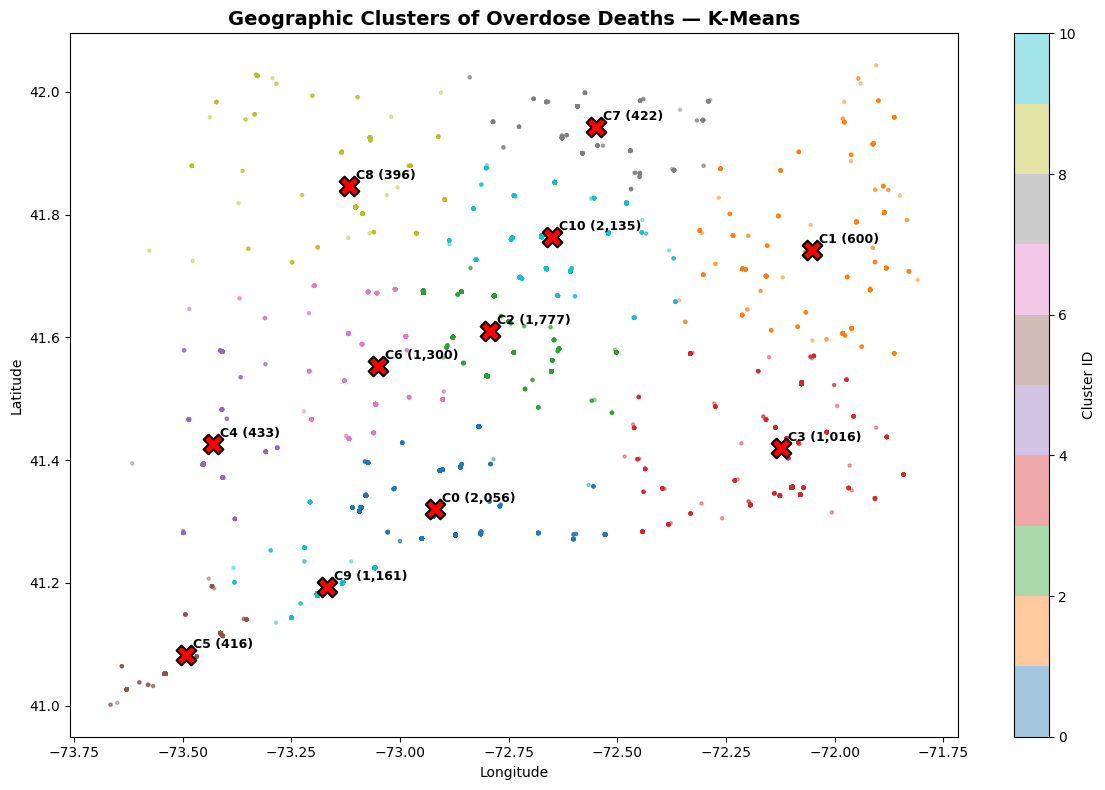

In [41]:
# 4.1.5 — Geographic Cluster Map
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(geo_df['Injury_Lon'], geo_df['Injury_Lat'],
                     c=geo_df['KMeans_Cluster'], cmap='tab10', s=5, alpha=0.4)

for i, (lat, lon) in enumerate(centres):
    count = (geo_df['KMeans_Cluster'] == i).sum()
    ax.scatter(lon, lat, c='red', marker='X', s=200, edgecolors='black', 
               linewidths=1.5, zorder=5)
    ax.annotate(f'C{i} ({count:,})', xy=(lon, lat), xytext=(5, 5),
                textcoords='offset points', fontsize=9, fontweight='bold')

ax.set_title('Geographic Clusters of Overdose Deaths — K-Means', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.colorbar(scatter, label='Cluster ID')
plt.tight_layout()
plt.savefig('viz_geographic_clusters.png', dpi=150, bbox_inches='tight')
plt.show()


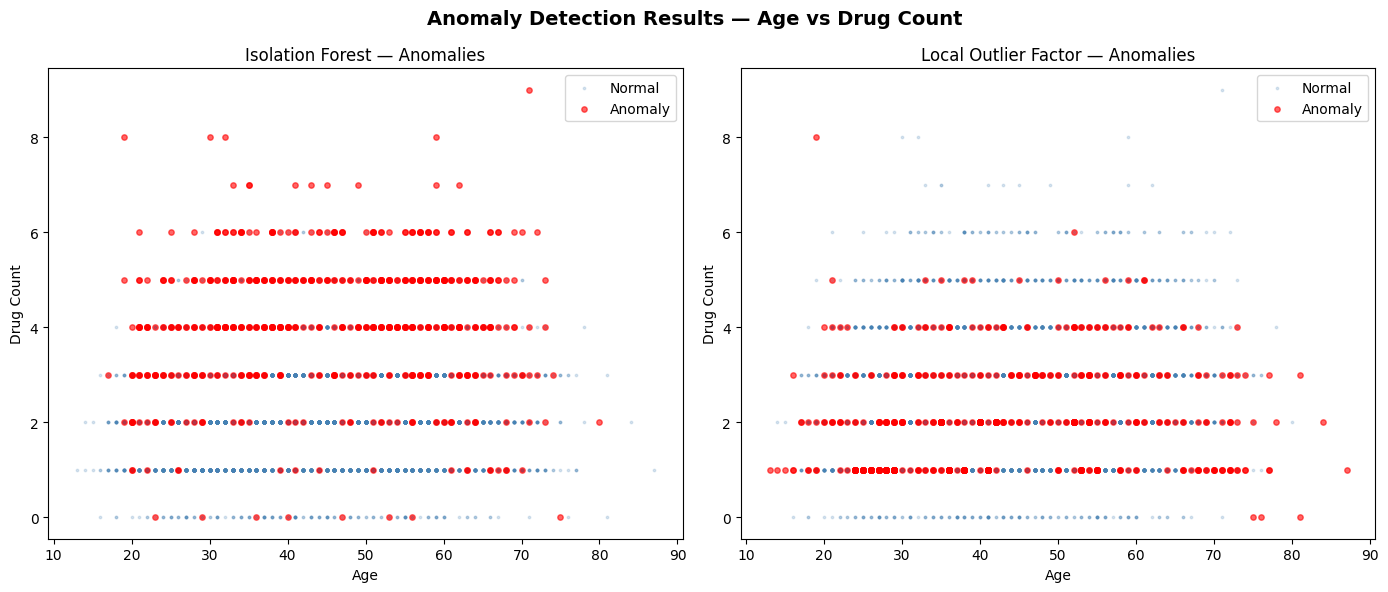

In [42]:
# 4.1.6 — Anomaly Detection Scatter Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, acol, title in [
    (axes[0], 'IF_Anomaly', 'Isolation Forest'),
    (axes[1], 'LOF_Anomaly', 'Local Outlier Factor')]:
    normal = df[df[acol] == 0]
    anomaly = df[df[acol] == 1]
    ax.scatter(normal['Age'], normal['Drug_Count'], c='steelblue', s=3, alpha=0.2, label='Normal')
    ax.scatter(anomaly['Age'], anomaly['Drug_Count'], c='red', s=15, alpha=0.6, label='Anomaly')
    ax.set_title(f'{title} — Anomalies')
    ax.set_xlabel('Age')
    ax.set_ylabel('Drug Count')
    ax.legend()

plt.suptitle('Anomaly Detection Results — Age vs Drug Count', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()
